# Tutorial: Intestine Neighborhood-Level Border Analysis

This notebook documents the neighborhood-scale intestine workflow used to support the manuscript's border-analysis section. It moves from data import to centroid construction, Gaussian-mixture probabilities, positive-membership counting, and region-level visualization of border-associated cell types.

What this notebook is designed for:
- per-cell neighborhood membership probabilities rather than a single discrete label
- thresholded multi-neighborhood algorithm that defines "border cells"
- figure-ready visualizations for spatial summaries and cell-type enrichment plots

Main user-adjustable controls:
- dataset path and region selections
- analysis columns for cell type, neighborhood, and region
- the local neighborhood scale `k` and probability thresholds
- saved output filenames and downstream plotting subsets

Relevant source modules:
- `src/mingle/pp/preprocessing.py`
- `src/mingle/tl/centroids.py`
- `src/mingle/tl/gmm.py`
- `src/mingle/tl/edges.py`
- plotting helpers under `src/mingle/pl/`

**Update timestamp:** 2026-03-19 15:48:31 -04:00


## 0. Import package dependencies

Import the analysis libraries used throughout this neighborhood-level intestine workflow.


In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import MINGLE as mg
import seaborn as sns
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


## 1. Load the intestine dataset

Read the intestine spatial table into an `AnnData` object and inspect the imported observation metadata before setting the analysis columns.


In [ ]:
file_path = r"/Volumes/data/MINGLE/Data/Intestine/05_25_HuBMAP_tunit.csv"
cells = mg.pp.read_file(file_path)

In [63]:
cells.obs

,Unnamed: 0,MUC2,SOX9,MUC1,CD31,Synapto,CD49f,CD15,CHGA,CDX2,...,machine,MUC6,Neighborhood,Neighborhood_Ind,Neigh_sub,NeighInd_sub,Community,Major Community,Tissue Segment,Tissue Unit
0,0,-0.303994,-0.163727,-0.587608,-0.212903,0.164173,-0.664863,0.049305,0.003616,-0.377532,...,NaN,NaN,Mature Epithelial,Mature Epithelial,Epithelial,Epithelial,Plasma Cell Enriched,Immune,Mucosa,Mucosa
1,1,-0.301927,-0.491706,-0.500804,-0.243205,-0.142568,-0.664861,-0.182627,-0.117573,-0.182754,...,NaN,NaN,Transit Amplifying Zone,Mature Epithelial,Epithelial,Epithelial,Mature Epithelial,Epithelial,Mucosa,Mucosa
2,2,-0.302206,-0.547234,-0.510705,-0.235309,-0.217185,-0.622758,-0.296486,-0.091504,-0.268055,...,NaN,NaN,Innate Immune Enriched,Innate Immune Enriched,Immune,Immune,Innate Immune Enriched,Immune,Mucosa,Mucosa
3,3,-0.294644,-0.615593,-0.570580,-0.247548,-0.042246,-0.642230,-0.299031,-0.121458,-0.377533,...,NaN,NaN,Outer Follicle,Outer Follicle,Immune,Immune,Follicle,Immune,Mucosa,Mucosa
4,4,-0.298609,-0.272162,-0.587607,-0.228376,-0.266695,-0.664864,-0.237499,-0.121460,-0.168489,...,NaN,NaN,Outer Follicle,Outer Follicle,Immune,Immune,Follicle,Immune,Mucosa,Mucosa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2511997,2603100,0.251624,-0.360296,-0.254984,-0.229060,0.154796,-0.218688,-0.350372,-0.112132,-0.142597,...,Skywalker,NaN,Innervated Stroma,Innervated Smooth Muscle,Stromal,Stromal,Stroma,Stroma,Subucosa,Muscularis externa
2511998,2603101,-0.274299,-0.465097,-0.367546,-0.210402,-0.204488,-0.259962,-0.333110,-0.103590,-0.213387,...,Skywalker,NaN,Stroma,Stroma,Stromal,Stromal,Stroma,Stroma,Subucosa,Muscularis externa
2511999,2603102,-0.260292,-0.397157,-0.352751,-0.200957,0.427470,-0.061012,-0.363492,-0.109572,-0.172711,...,Skywalker,NaN,Stroma,Smooth Muscle,Stromal,Stromal,Stroma,Stroma,Subucosa,Muscularis externa
2512000,2603103,-0.073782,-0.020896,-0.365204,-0.102411,-0.218278,-0.266579,-0.337989,-0.103707,-0.072134,...,Skywalker,NaN,Microvasculature,Microvasculature,Stromal,Stromal,Stroma,Stroma,Subucosa,Muscularis externa


## 2. Define annotation columns for downstream analysis

Specify the cell-type, neighborhood, and region columns that will be passed into the MINGLE tools.

Motivation:
These variables control both the biological resolution of the model and the geometric boundaries used when constructing KNN windows.

User-adjustable arguments:
- `cluster_col`: local composition feature space used by `KNN2` and `centroid_Calculation`
- `neighborhood_col`: label being modeled as the target neighborhood assignment
- `region_key`: passed to `KNN2` to keep windows inside each tissue region

Related source files:
- `src/mingle/tl/knn2.py`
- `src/mingle/tl/centroids.py`
- `src/mingle/tl/gmm.py`


In [3]:
cluster_col = "Cell Type"
neighborhood_col = "Neighborhood"
region_key = "unique_region"

## 3. Compute neighborhood centroids

`mg.tl.centroid_Calculation` in `src/mingle/tl/centroids.py` summarizes local cellular composition around each annotated neighborhood.

Motivation:
The code below creates the reference centroid matrix used by the later GMM probability calculation.

User-adjustable arguments:
- `k`: neighborhood size
- `cluster_col`: feature labels counted within windows
- `neighborhood_col`: neighborhood grouping variable
- `region_col`: region boundary variable
- `store_key`: optional cache key if you want to retain the centroid object in `adata.uns`

Practical guidance:
- larger `k` captures broader context but can blur sharp boundaries
- smaller `k` is more local but may be noisier
- k=10 for neighborhood centroids
- k=100 for community centroids
- k=300 for tissue unit centroids


In [ ]:
centroids = mg.tl.centroid_Calculation(cells, k=10, cluster_col=cluster_col, neighborhood_col=neighborhood_col, region_col=region_key)

Example dummy cols: ['Cell Type__B', 'Cell Type__CD4+ T cell', 'Cell Type__CD57+ Enterocyte', 'Cell Type__CD66+ Enterocyte', 'Cell Type__CD7+ Immune']


/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


{5:               x       y   unique_region         Cell Type    B  CD4+ T cell  \
0        3984.0  3387.0  B004_Ascending                NK  0.0          0.0   
1        5188.0  4116.0  B004_Ascending                NK  0.0          0.0   
2        6070.0  3146.0  B004_Ascending                NK  0.0          0.0   
3        6792.0  3891.0  B004_Ascending                NK  0.0          2.0   
4        7968.0  6351.0  B004_Ascending                NK  1.0          3.0   
...         ...     ...             ...               ...  ...          ...   
2511997  7633.0   353.0      B008_Trans                DC  0.0          0.0   
2511998  4921.0   533.0      B008_Trans                DC  0.0          0.0   
2511999  3710.0  6049.0      B008_Trans                DC  0.0          0.0   
2512000  5823.0   794.0      B008_Trans                DC  0.0          0.0   
2512001  2097.0  3363.0      B008_Trans  CD66+ Enterocyte  0.0          0.0   

         CD57+ Enterocyte  CD66+ Enterocyte  CD

## 4. Inspect the centroid output

Review the centroid matrix to confirm that the neighborhood-level features were assembled correctly. Check for sparcity, infinate values, or NaNs.


In [67]:
centroids.X

array([[1.13519803e-02, 1.22744106e-01, 7.61998367e+00, 1.23899674e+00,
        3.05373911e-02, 1.98410794e-01, 1.61351338e-01, 4.56189275e-01,
        1.28528833e-01, 4.39011604e-01, 2.28857324e-02, 1.98664203e-01,
        4.37936299e-02, 2.66295582e-01, 2.32752394e-02, 1.61429569e-01,
        4.69360918e-01, 7.48633981e-01, 7.10245371e-02, 3.03962260e-01,
        7.34005310e-03, 9.44945142e-02, 4.26251069e-02, 2.22650364e-01,
        7.96698689e-01, 9.16938663e-01, 1.28191253e-02, 1.22272834e-01,
        2.93429010e-02, 1.83471575e-01, 2.41061882e-03, 5.32176010e-02,
        1.27066011e-02, 1.31677777e-01, 6.58916906e-02, 3.07119966e-01,
        9.61564258e-02, 3.77460510e-01, 5.94475046e-02, 2.91451037e-01,
        6.69649988e-02, 2.82147974e-01, 1.45048276e-01, 4.19754058e-01,
        1.43468603e-02, 1.27928287e-01, 1.42083690e-02, 1.25111014e-01,
        5.18997163e-02, 2.73680001e-01],
       [1.89226493e-02, 1.72376126e-01, 3.21931577e+00, 1.96540713e+00,
        1.45402372e-01,

## 5. Compute cluster membership probabilities

Run `mg.tl.cpu_gmm_probability` from `src/mingle/tl/gmm.py` to estimate each cell's probability of membership across the annotated neighborhoods.

Motivation:
This produces the central output used by the rest of the notebook: the per-cell neighborhood probability matrix in `adata.obsm`.

User-adjustable arguments:
- `cluster_col`, `neighborhood_col`, `region_key`: analysis metadata
- `ks` and `k`: available and selected neighborhood sizes
- `num_processes`: CPU parallelism, choose the number of CPU cores that you would like to use to parallelize this calculation. Do not use specify more cores than your machine has. The default is to use the total number of cores from your machine. 

Important implementation note:
The source stores probabilities in `adata.obsm[prob_key]` and stores neighborhood names in `adata.uns[prob_variable_key]`. You must set your ``prob_key`` and ``prob_variable_key`` to be unique for each level that you run analysis (i.e., "neighborhood_probabilities" for neighborhood level and "community_probabilities for community level etc.).

This step may take a while when using CPU, therefore, we have also created a GPU accelerated version of this step. In order to access it in the package, you will need to load it in separately using ``import MINGLE.tl.gpu_gmm as gpu_gmm``. Importantly, this requires your installation of ``cupy`` into your MINGLE environment and access to a GPU on your machine.

In this example notebook, we will use the CPU version of MINGLE.


In [ ]:
mg.tl.cpu_gmm_probability(CELLS_ADATA=cells, CENTROIDS_ADATA=centroids, cluster_col=cluster_col, neighborhood_col=neighborhood_col, region_key=region_key, num_processes=32)

Example dummy cols: ['Cell Type__B', 'Cell Type__CD4+ T cell', 'Cell Type__CD57+ Enterocyte', 'Cell Type__CD66+ Enterocyte', 'Cell Type__CD7+ Immune']
Using 14 processes.


/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprec

AnnData object with n_obs × n_vars = 2512002 × 0
    obs: 'Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163', 'CD161', 'first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP', 'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region', 'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location', 'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine', 'MUC6', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit'
    uns: 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

In [ ]:
# GPU accelerated version of MINGLE gmm

#import MINGLE.tl.update_gpu_gmm as gpu_gmm

#gpu_gmm.gpu_gmm_probability(cells, centroids, cluster_col= cluster_col, neighborhood_col= neighborhood_col, region_key= region_key, k= 10, 
                            #batch_size= 20000, prob_key = 'neighborhood_probability', prob_variable_key = "neighborhood_probability_neighborhoods")

## 6. Count positive neighborhood memberships

Use `mg.tl.findPositives` to summarize how many neighborhood probabilities exceed the selected threshold for each cell.

Importantly, you must change the ``prob_key`` to match the adata.obsm probability key above. Also, if you plan to run this analysis at multiple levels, ensure you have a unique ``result_key`` such as "neighborhood_Count_Above_Threshold".


In [ ]:
mg.tl.findPositives(cells, prob_key= "neighborhood_probabilities", threshold= 0.25, result_key= "Count_Above_Threshold")

AnnData object with n_obs × n_vars = 2512002 × 0
    obs: 'Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163', 'CD161', 'first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP', 'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region', 'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location', 'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine', 'MUC6', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit', 'Count_Above_Threshold'
    uns: 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

## 7. Save and reload processed results

Save your `AnnData` object with the data you have calculated. Specify the file path where you would like to save your data.


In [70]:
cells.write_h5ad("intestine_results.h5ad", compression="gzip")

If you have to pause here and come back at a later time, you can load your saved data back in later.

In [4]:
cells = ad.read_h5ad("intestine_results.h5ad")

## 8. Supplemental spatial analysis

Construct a probability table aligned to the original observations and prepare the metadata required for the downstream intestine region visualizations.

Why this section matters biologically:
The manuscript uses these aligned probability tables to move from abstract probability vectors back into tissue space, where border cells can be compared against anatomical organization. At the neighborhood scale, the expectation is that border-associated cells concentrate where adjacent neighborhood programs meet rather than appearing uniformly across the tissue.

Common user-adjustable inputs in the following cells:
- which columns from `cells.obs` are copied into `df_probabilities`
- which region is chosen for focused plotting
- which metadata column is treated as the cell-type label in downstream summaries


In [5]:
df_probabilities = pd.DataFrame(
    cells.obsm["neighborhood_probabilities"],
    index=cells.obs_names,  # restores cell index
    columns=cells.uns["neighborhood_probability_neighborhoods"]
)
threshold = 0.25

neighborhoods_to_loop = [
    'Innate Immune Enriched', 'Outer Follicle', 'Plasma Cell Enriched',
    'Transit Amplifying Zone', 'Adaptive Immune Enriched', 'Stroma',
    'Paneth Enriched', 'Smooth Muscle & Innate Immune', 'Mature Epithelial',
    'Microvasculature', 'CD8+ T Enriched IEL', 'Stroma & Innate Immune',
    'Macrovasculature', 'Innervated Stroma', 'Secretory Epithelial',
    'Innervated Smooth Muscle', 'Smooth Muscle', 'Glandular Epithelial',
    'CD66+ Mature Epithelial', 'Inner Follicle'
]
df_probabilities


,Mature Epithelial,Transit Amplifying Zone,Innate Immune Enriched,Outer Follicle,Adaptive Immune Enriched,Secretory Epithelial,CD66+ Mature Epithelial,Plasma Cell Enriched,Stroma & Innate Immune,Smooth Muscle & Innate Immune,Microvasculature,Innervated Stroma,Inner Follicle,Glandular Epithelial,CD8+ T Enriched IEL,Macrovasculature,Smooth Muscle,Paneth Enriched,Stroma,Innervated Smooth Muscle
0,9.621431e-17,1.738263e-05,2.550602e-09,1.034919e-15,8.399542e-15,1.038487e-12,9.999138e-01,4.719363e-06,4.700611e-29,7.105267e-35,1.141756e-23,4.150950e-51,2.223297e-18,5.369941e-05,1.036248e-05,1.558331e-64,1.976448e-303,3.776937e-08,1.377453e-25,1.474823e-119
1,7.565365e-05,4.341072e-01,2.973325e-07,3.763595e-17,1.061069e-13,8.112247e-09,6.889988e-02,1.245979e-04,1.987569e-26,3.430428e-38,5.761640e-24,4.459261e-71,1.398810e-24,4.149381e-01,8.185425e-02,3.613787e-72,0.000000e+00,1.407577e-12,8.154054e-22,1.690427e-136
2,2.077225e-251,1.906601e-38,9.010531e-01,4.356110e-13,2.150723e-05,2.055140e-50,6.890222e-304,1.152867e-13,1.855804e-05,1.485486e-15,7.426432e-14,9.791116e-02,1.770380e-40,7.495798e-12,3.523088e-78,2.472484e-20,2.083321e-127,1.413461e-30,9.956257e-04,2.779748e-37
3,4.766160e-93,2.347692e-26,2.475441e-09,9.999945e-01,5.495623e-06,8.660689e-39,2.612746e-96,5.806880e-10,1.682503e-20,5.936828e-24,1.486119e-18,2.166350e-26,7.864169e-11,2.986772e-33,1.478329e-29,6.687419e-34,6.137253e-240,2.272451e-20,1.401548e-26,4.732211e-77
4,0.000000e+00,1.145963e-65,3.530590e-30,1.226926e-03,3.682371e-13,7.241753e-67,8.941592e-267,4.700092e-25,1.222916e-54,6.636910e-70,7.213891e-47,2.227342e-125,9.987731e-01,4.984005e-236,9.755718e-85,1.454423e-103,0.000000e+00,8.794790e-113,2.916071e-120,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2511997,4.581918e-203,4.608746e-33,1.970248e-09,7.919364e-13,2.928838e-10,1.219899e-37,5.377257e-231,3.242233e-13,5.407687e-08,8.500487e-08,4.930692e-11,9.999924e-01,2.798641e-36,5.131719e-21,4.176581e-57,1.416124e-07,2.061919e-24,5.013783e-19,2.249583e-06,5.102952e-06
2511998,8.485623e-82,8.254226e-33,1.569894e-19,1.512807e-20,6.657414e-22,5.383169e-51,4.449668e-81,4.751249e-22,2.613071e-05,1.438220e-41,1.188817e-10,7.711651e-06,7.133464e-32,1.469706e-21,2.036598e-54,2.811911e-15,6.439844e-37,6.807966e-35,9.999649e-01,1.305761e-06
2511999,7.388284e-78,6.616400e-25,5.009822e-15,6.064712e-16,8.017500e-17,3.440823e-36,2.503621e-87,5.531373e-16,1.018958e-06,9.018368e-21,2.064286e-09,1.073040e-04,2.315844e-23,6.898246e-19,3.088471e-42,9.150280e-07,1.159200e-15,2.699024e-25,8.439665e-04,9.990468e-01
2512000,1.583859e-87,6.558047e-20,5.945148e-08,5.355660e-11,2.084210e-10,1.377566e-28,2.112087e-50,8.737761e-08,4.022963e-05,6.466737e-16,3.564131e-01,1.629935e-07,1.053726e-12,1.450950e-14,6.920848e-29,6.416650e-01,2.199116e-29,4.898466e-22,1.881360e-03,8.273094e-11


In [6]:
for i in ['Community','Tissue Unit','Neighborhood', 'Cell Type', 'unique_region', 'x','y', 'Count_Above_Threshold']:
    df_probabilities[i] = cells.obs[i]
df_probabilities
filtered_cells = df_probabilities

### Figure 1b

Plot the probability distributions of cells across the dataset and thier number of "positive neighborhoods". A "positive neighborhood" is a neighborhood that has a probability greater than the selected threshold for a cell.

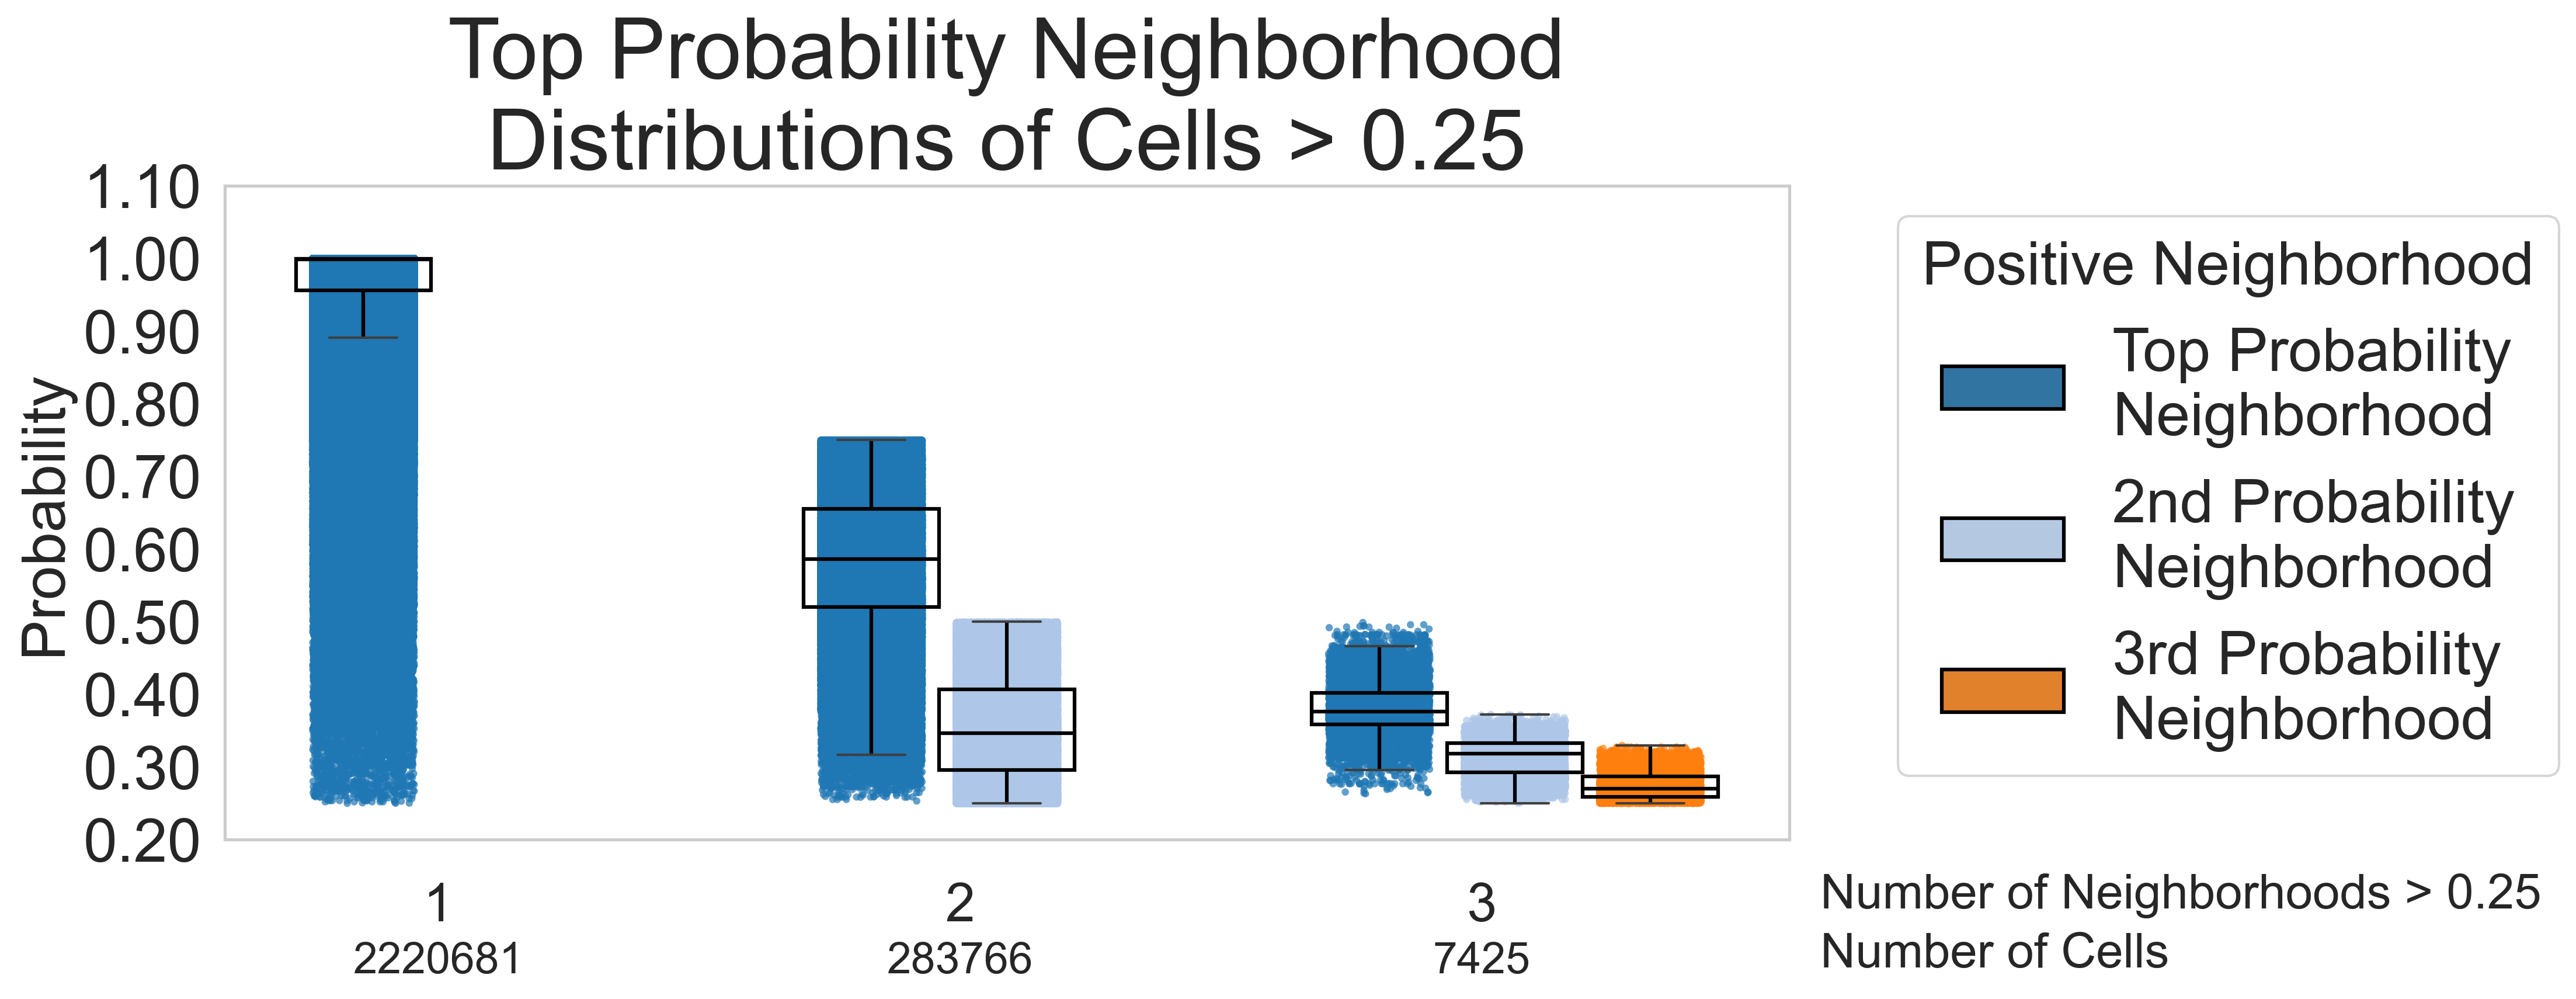

In [86]:
# Copy the neighborhood probabilities
df_probs = filtered_cells[neighborhoods_to_loop].copy()

# Get sorted neighborhood names based on probabilities > threshold
sorted_neighs = df_probs.apply(
    lambda row: row[row > threshold].sort_values(ascending=False).index.tolist(),
    axis=1
)

# Extract top N (up to 3) and save to new columns
filtered_cells['Neighborhood1'] = sorted_neighs.apply(lambda x: x[0] if len(x) > 0 else None)
filtered_cells['Neighborhood2'] = sorted_neighs.apply(lambda x: x[1] if len(x) > 1 else None)
filtered_cells['Neighborhood3'] = sorted_neighs.apply(lambda x: x[2] if len(x) > 2 else None)

# Include rows with 1, 2, or 3 positive neighborhoods
subset = filtered_cells[filtered_cells['Count_Above_Threshold'].isin([1, 2, 3])].copy()

# Get the probabilities for each of the top 3 neighborhoods (even for 1 positive)
subset['Prob1'] = subset.apply(lambda row: row[row['Neighborhood1']] if pd.notna(row['Neighborhood1']) else None, axis=1)
subset['Prob2'] = subset.apply(lambda row: row[row['Neighborhood2']] if pd.notna(row['Neighborhood2']) else None, axis=1)
subset['Prob3'] = subset.apply(lambda row: row[row['Neighborhood3']] if pd.notna(row['Neighborhood3']) else None, axis=1)

# Reshape to long format
long_df = pd.melt(
    subset,
    id_vars='Count_Above_Threshold',
    value_vars=['Prob1', 'Prob2', 'Prob3'],
    var_name='NeighborhoodOrder',
    value_name='Probability'
)

# Keep only relevant rows for each count (e.g., for 1, only keep Prob1)
long_df = long_df[~((long_df['Count_Above_Threshold'] == 1) & (long_df['NeighborhoodOrder'] == 'Prob2'))]
long_df = long_df[~((long_df['Count_Above_Threshold'] == 1) & (long_df['NeighborhoodOrder'] == 'Prob3'))]
import matplotlib.pyplot as plt
import seaborn as sns

# Set up figure and axes
fig, ax = plt.subplots(figsize=(15, 6), dpi=300)

# Stripplot in the background
sns.stripplot(
    data=long_df,
    x='Count_Above_Threshold',
    y='Probability',
    hue='NeighborhoodOrder',
    dodge=True,
    jitter=0.3,
    alpha=0.7,
    s=3,
    palette='tab20',
    zorder=1,
    ax=ax
)

# Boxplot on top
sns.boxplot(
    data=long_df,
    x='Count_Above_Threshold',
    y='Probability',
    hue='NeighborhoodOrder',
    dodge=True,
    palette='tab20',
    showcaps=True,
    boxprops={'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black', 'linewidth': 1.5},
    medianprops={'color': 'black', 'linewidth': 1.5},
    showfliers=False,
    zorder=2,
    ax=ax
)

# Clean up extra legend duplicates and relabel
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# New label mapping
label_mapping = {
    'Prob1': 'Top Probability\nNeighborhood',
    'Prob2': '2nd Probability\nNeighborhood',
    'Prob3': '3rd Probability\nNeighborhood'
}

# Rebuild deduplicated, relabeled legend
new_handles_labels = [(by_label[key], label_mapping[key]) for key in by_label if key in label_mapping]

ax.legend(
    [hl[0] for hl in new_handles_labels],
    [hl[1] for hl in new_handles_labels],
    title='Positive Neighborhood',
    title_fontsize=25,
    fontsize=25,
    markerscale=10,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# X-axis tick labels: dual rows
xtick_categories = sorted(long_df['Count_Above_Threshold'].unique())
cell_counts = subset['Count_Above_Threshold'].value_counts().sort_index()
num_xticks = len(xtick_categories)

# First row: number of neighborhoods
neigh_labels = [str(val) for val in xtick_categories]

# Second row: number of cells (N = ...)
count_labels = [f'{cell_counts.get(val, 0)}' for val in xtick_categories]

# Remove default x-axis labels
ax.set_xticks(range(num_xticks))
ax.set_xticklabels(['' for _ in range(num_xticks)])

# Add custom dual-line x-axis labels (in axes fraction coords)
for i, (neigh, count) in enumerate(zip(neigh_labels, count_labels)):
    xpos = (i + 0.5) / num_xticks  # center of each bar
    ax.text(xpos - 0.03, -0.065, neigh, fontsize=22, ha='center', va='top', transform=ax.transAxes)
    ax.text(xpos - 0.03, -0.155, count, fontsize=18, ha='center', va='top', transform=ax.transAxes)

# Add horizontal lines at label rows (in axes fraction coords)
line_y_positions = [-0.085, -0.175]
for y in line_y_positions:
    ax.hlines(
        y=y,
        xmin=0, xmax=1,
        color='gray',
        linewidth=1,
        transform=ax.transAxes,
        linestyles='dotted'
    )

# Right-side "titles" aligned with the lines
ax.text(1.02, line_y_positions[0], 'Number of Neighborhoods > 0.25', fontsize=20, ha='left', va='center', transform=ax.transAxes)
ax.text(1.02, line_y_positions[1], 'Number of Cells', fontsize=20, ha='left', va='center', transform=ax.transAxes)

# Y-axis formatting
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=25)

# Titles and axis labels
ax.set_title('Top Probability Neighborhood\nDistributions of Cells > 0.25', fontsize=35)
ax.set_xlabel('')
ax.set_ylabel('Probability', fontsize=25)

# Final tweaks
ax.grid(False)
fig.tight_layout()
plt.show()



### Create a custom palette for cell types and neighborhoods in the dataset.

Note:
Using a fixed palette is important here because the manuscript compares the same cell types across multiple border-focused panels. If you adapt this notebook to a different dataset, regenerate the palette only after confirming the final cell-type vocabulary.

In [89]:
def make_celltype_palette_strict(df, cell_type_col='Cell_Type'):
    """
    Create a long, non-repeating categorical color palette for each unique cell type.
    Uses a combination of seaborn/matplotlib categorical palettes.
    """
    import seaborn as sns

    # Get unique cell types
    cell_types = sorted(df[cell_type_col].dropna().unique())
    n = len(cell_types)

    # Combine multiple qualitative palettes
    palette_names = ['tab20', 'Set3', 'Set2', 'Paired', 'Dark2', 'Accent']
    combined_colors = []

    for name in palette_names:
        combined_colors.extend(sns.color_palette(name))

    if len(combined_colors) < n:
        raise ValueError(f"Not enough distinct colors for {n} cell types. Max supported is {len(combined_colors)}.")

    # Slice and assign
    final_palette = combined_colors[:n]
    color_dict = dict(zip(cell_types, final_palette))
    return color_dict, final_palette, cell_types

In [91]:
# Create the palette once
color_dict, color_list, cell_type_list = make_celltype_palette_strict(df_probabilities, cell_type_col='Cell Type')

# Print or check mapping
print(color_dict)

{'B': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'CD4+ T cell': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274), 'CD57+ Enterocyte': (1.0, 0.4980392156862745, 0.054901960784313725), 'CD66+ Enterocyte': (1.0, 0.7333333333333333, 0.47058823529411764), 'CD7+ Immune': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), 'CD8+ T': (0.596078431372549, 0.8745098039215686, 0.5411764705882353), 'Cycling TA': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), 'DC': (1.0, 0.596078431372549, 0.5882352941176471), 'Endothelial': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), 'Enterocyte': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589), 'Goblet': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354), 'ICC': (0.7686274509803922, 0.611764705882353, 0.5803921568627451), 'Lymphatic': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902), 'M1 Macrophage': (0.9686274509803922, 0.7137254901960784, 0.823529411

In [97]:
# Create the palette once
neigh_dict, color_list, cell_type_list = make_celltype_palette_strict(df_probabilities, cell_type_col='Neighborhood')

# Print or check mapping
print(neigh_dict)

{'Adaptive Immune Enriched': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'CD66+ Mature Epithelial': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274), 'CD8+ T Enriched IEL': (1.0, 0.4980392156862745, 0.054901960784313725), 'Glandular Epithelial': (1.0, 0.7333333333333333, 0.47058823529411764), 'Innate Immune Enriched': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), 'Inner Follicle': (0.596078431372549, 0.8745098039215686, 0.5411764705882353), 'Innervated Smooth Muscle': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), 'Innervated Stroma': (1.0, 0.596078431372549, 0.5882352941176471), 'Macrovasculature': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), 'Mature Epithelial': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589), 'Microvasculature': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354), 'Outer Follicle': (0.7686274509803922, 0.611764705882353, 0.5803921568627451), 'Paneth Enriched': (0

### Supplemental Figure 1j

Plot the proportion of each cell type in the dataset that is classified as a border cell.


/var/folders/6b/mntkh0r931zc2_rw968nmljh0000gn/T/ipykernel_1433/2292822563.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


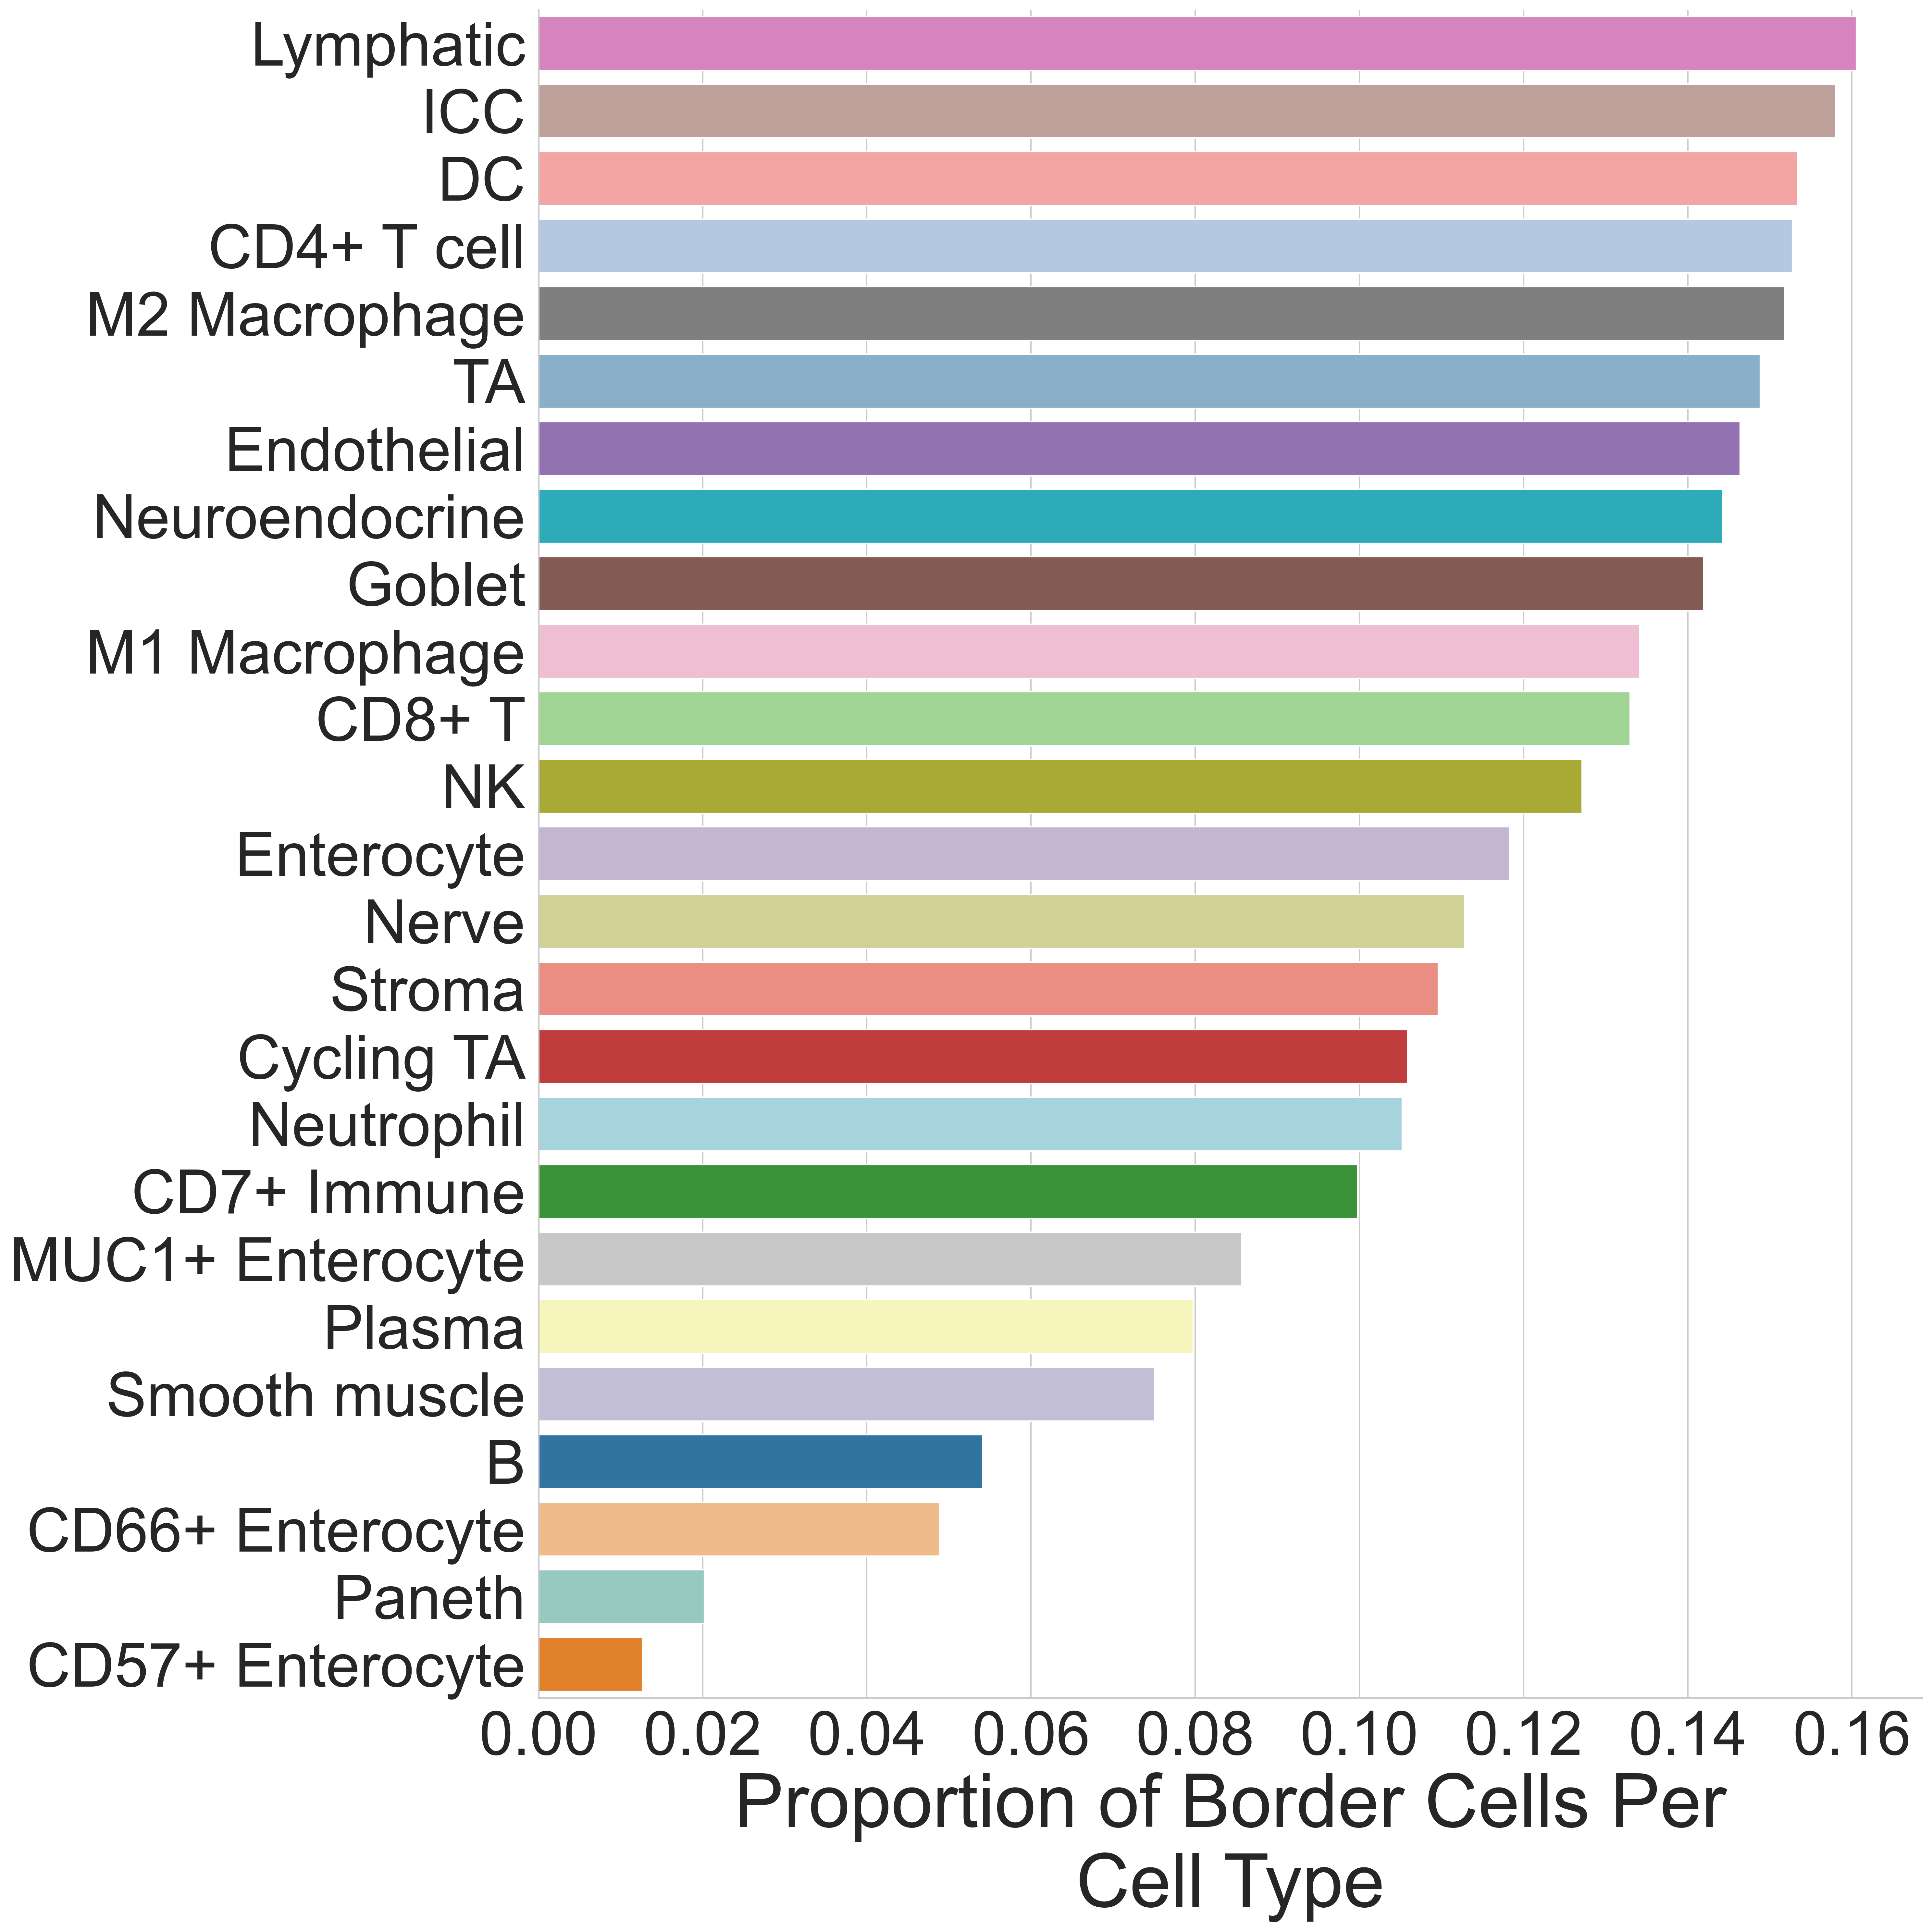

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for cells where Count_Above_Threshold == 2 or 3
subset = filtered_cells[filtered_cells['Count_Above_Threshold'].isin([2, 3])]

# Total counts per cell type in the full dataset
total_counts = filtered_cells['Cell Type'].value_counts()

# Subset counts per cell type (only those positive for more than one neighborhood)
subset_counts = subset['Cell Type'].value_counts()

# Compute proportion per cell type
proportion_df = (subset_counts / total_counts).reset_index()
proportion_df.columns = ['Cell Type', 'Proportion']

# Optional: sort by proportion
proportion_df = proportion_df.sort_values(by='Proportion', ascending=False)

# Plot
plt.figure(figsize=(20, 20), dpi=300)
order = (
    proportion_df
    .sort_values('Proportion', ascending=False)
    ['Cell Type']
)
sns.barplot(
    data=proportion_df,
    y='Cell Type',
    x='Proportion',
    order=order,
    palette=color_dict
)

# Remove box spines except left & bottom
sns.despine(top=True, right=True)

# Labels and formatting
plt.title('', fontsize=35)
plt.xlabel('Proportion of Border Cells Per\nCell Type', fontsize=55)
plt.ylabel('', fontsize=35)
plt.yticks(fontsize=45)
plt.xticks(fontsize=45)
plt.tight_layout()
plt.show()


### Supplemental Figure 1k

Plot the proportion of each cell neighborhood annotations in the dataset that are classified as a border cell.


/var/folders/6b/mntkh0r931zc2_rw968nmljh0000gn/T/ipykernel_1433/1490209855.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


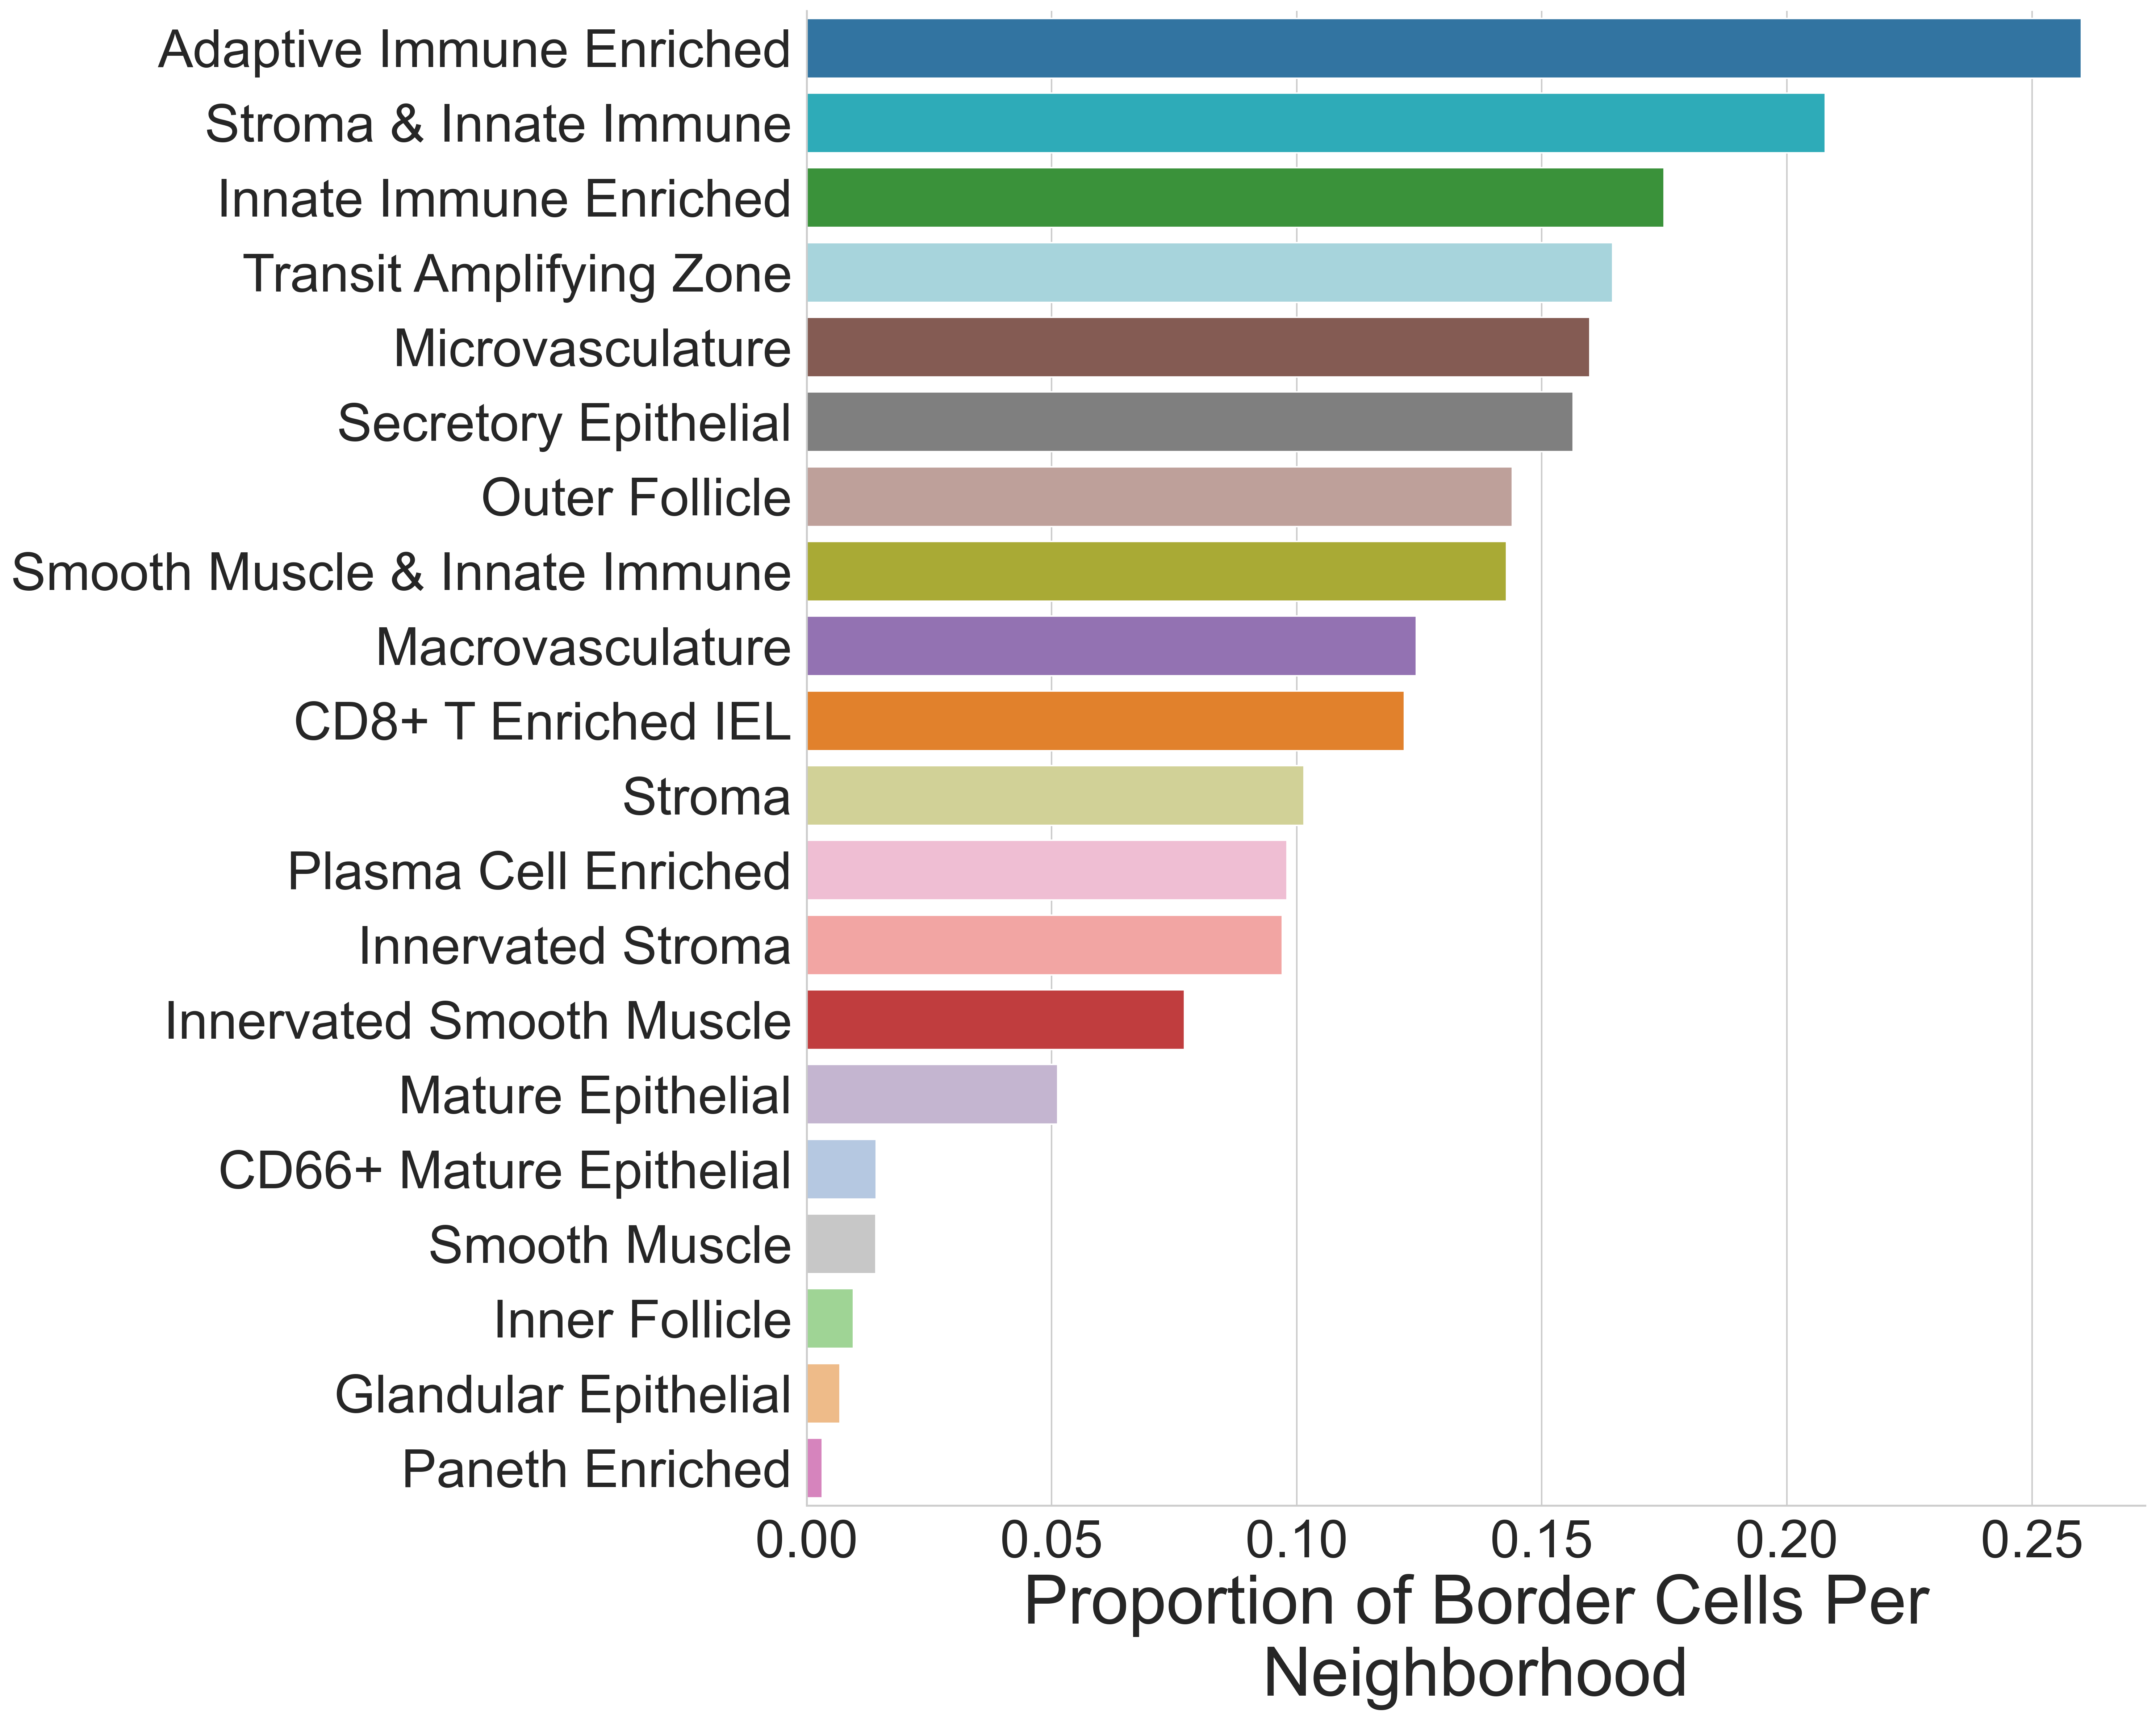

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for cells where Count_Above_Threshold == 2 or 3
subset = filtered_cells[filtered_cells['Count_Above_Threshold'].isin([2, 3])]

# Total counts per cell type in the full dataset
total_counts = filtered_cells['Neighborhood'].value_counts()

# Subset counts per cell type (only those positive for more than one neighborhood)
subset_counts = subset['Neighborhood'].value_counts()

# Compute proportion per cell type
proportion_df = (subset_counts / total_counts).reset_index()
proportion_df.columns = ['Neighborhood', 'Proportion']

# Optional: sort by proportion
proportion_df = proportion_df.sort_values(by='Proportion', ascending=False)

# Plot
plt.figure(figsize=(20, 16), dpi=300)
order = (
    proportion_df
    .sort_values('Proportion', ascending=False)
    ['Neighborhood']
)
sns.barplot(
    data=proportion_df,
    y='Neighborhood',
    x='Proportion',
    order = order,
    palette=neigh_dict
)

# Remove box spines except left & bottom
sns.despine(top=True, right=True)

# Labels and formatting
plt.title('', fontsize=35)
plt.xlabel('Proportion of Border Cells Per\nNeighborhood', fontsize=45)
plt.ylabel('', fontsize=35)
plt.yticks(fontsize=35)
plt.xticks(fontsize=35)
plt.tight_layout()
plt.show()
